# Model Improvement and Selection

This notebook trains and evaluates improved machine-learning models for the Board Game Rating Predictor project.

The previous notebook established two initial models:

- a dummy baseline model
- a Linear Regression model

Linear Regression performed better than the dummy baseline, which showed that the prepared board game features contain useful predictive information.

This notebook will now try more flexible models, compare model performance, review feature importance, and select a best model for later use.

In [308]:
# Import libraries used througout this notebook
# to store trained Random Forest model as file and load again later
import joblib
# numpy is used to calculate RMSE by taking square root of MSE
import numpy as np
import pandas as pd
# for simple feature-importance chart (visual representation)
import matplotlib.pyplot as plt

# Import Path for creating file paths that work
# reliably across different operating systems
from pathlib import Path

# Import improved regression modelling tools
# RandomForestRegressor -> tree-based regression model
# -> builds many decision trees and averages their predictions
from sklearn.ensemble import RandomForestRegressor

# Import model evaluation metrics
# 3 metric functions is to measure model error in a standard regression format
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [309]:
# Define current notebook folder and project rooot
current_folder = Path.cwd()
project_root = current_folder.parent

print("Current folder:", current_folder)
print("Project root:", project_root)

Current folder: c:\Users\Zombie\Desktop\vscode-projects\board-game-rating-predictor\notebooks
Project root: c:\Users\Zombie\Desktop\vscode-projects\board-game-rating-predictor


## Load Prepared Modelling Datasets

The prepared training and testing datasets are loaded from the `data/processed` folder.

These files were created during feature engineering and were also used in the baseline modelling notebook.

Using the same prepared datasets allows improved models to be compared fairly against the dummy baseline and Linear Regression models.

In [310]:
# Define paths to the prepared modelling dataset files
# -> htis will confirms notebook 6 can find processed data folder
#  before trying loading files from it
processed_data_folder = project_root / "data" / "processed"

x_train_path = processed_data_folder / "x_train_prepared.csv"
x_test_path = processed_data_folder / "x_test_prepared.csv"
y_train_path = processed_data_folder / "y_train.csv"
y_test_path = processed_data_folder / "y_test.csv"

model_feature_names_path = processed_data_folder / "model_feature_names.csv"

print("Processed data folder:", processed_data_folder)
print("Folder exists:", processed_data_folder.exists())

Processed data folder: c:\Users\Zombie\Desktop\vscode-projects\board-game-rating-predictor\data\processed
Folder exists: True


In [311]:
# Verify that all required prepared modelling files exist
# Saefty check
prepared_file_paths = [
    x_train_path,
    x_test_path,
    y_train_path,
    y_test_path,
    model_feature_names_path
]

for file_path in prepared_file_paths:
    print(file_path.name, "exists:", file_path.exists())

x_train_prepared.csv exists: True
x_test_prepared.csv exists: True
y_train.csv exists: True
y_test.csv exists: True
model_feature_names.csv exists: True


In [312]:
# Load prepared modelling datasets
X_train = pd.read_csv(x_train_path)
X_test = pd.read_csv(x_test_path)

y_train_data = pd.read_csv(y_train_path)
y_test_data = pd.read_csv(y_test_path)

model_feature_names = pd.read_csv(model_feature_names_path)

print("Prepared modelling datasets loaded successfully.")

Prepared modelling datasets loaded successfully.


In [313]:
# Define target column
target_column = "Rating Average"

# Convert target DataFrames into Series for modelling
# -> keeps the format consistent between other notebooks
y_train = y_train_data[target_column]
y_test = y_test_data[target_column]

print("y_train type:", type(y_train))
print("y_test type:", type(y_test))

y_train type: <class 'pandas.Series'>
y_test type: <class 'pandas.Series'>


In [314]:
# Check the shapes of the loaded modelling datasets
# -> confirmation same modelling data loaded as in notebook 5
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)
print("model_feature_names shape:", model_feature_names.shape)

X_train shape: (16273, 35)
X_test shape: (4069, 35)
y_train shape: (16273,)
y_test shape: (4069,)
model_feature_names shape: (35, 1)


In [315]:
# Verify that loaded feature columns match the saved model feature names
expected_feature_names = model_feature_names["Feature"].tolist()

x_train_columns_match = X_train.columns.tolist() == expected_feature_names
x_test_columns_match = X_test.columns.tolist() == expected_feature_names

print("X_train columns match saved feature names:", x_train_columns_match)
print("X_test columns match saved feature names:", x_test_columns_match)

X_train columns match saved feature names: True
X_test columns match saved feature names: True


In [316]:
# Check missing values in the loaded prepared datasets
# -> to cofirm feature engineering and imputation are preserved
print("Missing values in X_train:", X_train.isnull().sum().sum())
print("Missing values in X_test:", X_test.isnull().sum().sum())
print("Missing values in y_train:", y_train.isnull().sum())
print("Missing values in y_test:", y_test.isnull().sum())

Missing values in X_train: 0
Missing values in X_test: 0
Missing values in y_train: 0
Missing values in y_test: 0


### Prepared Modelling Dataset Load Result

The prepared modelling datasets were loaded successfully.

The training feature dataset contains 16,273 rows and 35 feature columns.

The testing feature dataset contains 4,069 rows and 35 feature columns.

The target values were converted into one-dimensional Series objects for modelling.

The loaded feature columns match the saved model feature names.

The loaded datasets contain no missing values and are ready for improved model training.

## Train Random Forest Regression Model

A Random Forest Regression model is trained as the first improved model.

Random Forest is more flexible than Linear Regression because it can learn non-linear relationships and interactions between features.

This model will be trained using the same prepared training data used by the previous models so that performance can be compared fairly.

In [317]:
# Create Random Forest Regression model
random_forest_model = RandomForestRegressor(
    # n_estimators=100 == forest will build 100 decision trees
    n_estimators=100,
    # random_state=42 == makes result reproducible
    random_state=42,
    # n_jobs=-1 == allows model to use available CPU cores
    n_jobs=-1
)

# Train Random Forest model using prepared training data
random_forest_model.fit(X_train, y_train)

print("Random Forest Regression model trained successfully.")

Random Forest Regression model trained successfully.


In [318]:
# Check the trained Random Forest model structure
print("Number of trees:", random_forest_model.n_estimators)
print("Random state:", random_forest_model.random_state)
print("Number of input features:", random_forest_model.n_features_in_)
print("Number of training features:", X_train.shape[1])

Number of trees: 100
Random state: 42
Number of input features: 35
Number of training features: 35


In [319]:
# Create Radnom Forest predictions for the training and testing feature sets
random_forest_train_predictions = random_forest_model.predict(X_train)
random_forest_test_predictions = random_forest_model.predict(X_test)

print("Random Forest train predictions shape:", random_forest_train_predictions.shape)
print("Random Forest test predictions shape:", random_forest_test_predictions.shape)

Random Forest train predictions shape: (16273,)
Random Forest test predictions shape: (4069,)


In [320]:
# Review dirstibution of Random Forest test predictions
# quick sanity check of prediction range
random_forest_test_prediction_summary = pd.Series(
    random_forest_test_predictions,
    name="Random Forest Test Predictions"
).describe()

random_forest_test_prediction_summary

count    4069.000000
mean        6.385815
std         0.708922
min         2.655400
25%         5.929200
50%         6.383100
75%         6.885100
max         8.402123
Name: Random Forest Test Predictions, dtype: float64

In [321]:
# Preview actual testing ratings beside Random Forest predictions
# -> Easy to read look at prediction
random_forest_prediction_preview = pd.DataFrame(
    {
        "Actual Rating": y_test.head(10).values,
        "Random Forest Prediction": random_forest_test_predictions[:10]
    }
)

random_forest_prediction_preview

,Actual Rating,Random Forest Prediction
0,6.23,6.52420
1,7.02,6.41930
2,6.96,7.13080
3,7.07,6.46770
4,8.88,7.66700
5,7.68,7.58775
6,6.88,7.08220
7,6.17,5.88200
8,7.53,7.07960
9,6.15,6.42940


### Random Forest Model Result

A Random Forest Regression model was trained using the prepared training dataset.

The model used 100 decision trees and all 35 prepared feature columns.

Predictions were created for both the training and testing datasets.

The Random Forest predictions will be evaluated and compared with the previous models in the next modelling step.

## Evaluate Random Forest Model Performance

The Random Forest Regression model is evaluated using common regression metrics.

The metircs used are:

- Mean Absolute Error, or MAE
- Root Mean Squared Error, or RMSE
- R-squared, or R2 (R on square)

MAE and RMSE measure prediction error, so lower values are better.

R2 (R on square) measures how much variation in the target is explained by the model, so higher values are better.

The model is evaluated on both the training set and the testing set so we can check whether it generalizes well to unseen data.

In [322]:
# Create reusable function for evaluating regression model performance
# same used in notebook5 -> notebook remains cleaner because model evaluation 
# happens without rewriting same metric code evetry time
def evaluate_regression_model(y_true, y_pred):
    """Calculate common regression evaluation metrics."""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    return {
        "MAE": float(mae),
        "RMSE": float(rmse),
        "R2": float(r2)
    }

In [323]:
# Evaluate the Random Forest model on training and testing data
# -> calculates MAE, RMSE, and R2 (R square) for the Random Forest model
random_forest_train_metrics = evaluate_regression_model(
    y_train,
    random_forest_train_predictions
)

random_forest_test_metrics = evaluate_regression_model(
    y_test,
    random_forest_test_predictions
)

print("Random Forest train metrics:", random_forest_train_metrics)
print("Random Forest test metrics:", random_forest_test_metrics)

Random Forest train metrics: {'MAE': 0.1839210699873878, 'RMSE': 0.24826333615381788, 'R2': 0.9294904784402906}
Random Forest test metrics: {'MAE': 0.4911510570047631, 'RMSE': 0.6649429553038372, 'R2': 0.4993247012615084}


In [324]:
# Create a Random Forest performance table for easeier read
random_forest_performance = pd.DataFrame(
    [
        {
            "Model": "Random Forest",
            "Dataset": "Train",
            **random_forest_train_metrics
        },
        {
            "Model": "Random Forest",
            "Dataset": "Test",
            **random_forest_test_metrics
        }
    ]
)

random_forest_performance

,Model,Dataset,MAE,RMSE,R2
0,Random Forest,Train,0.183921,0.248263,0.929490
1,Random Forest,Test,0.491151,0.664943,0.499325


In [325]:
# Same as previous table, but this one 
# create ruonded version of the Random Forest performance
# -> we keep "unrounded" in memory for exact calculations
random_forest_performance_rounded = random_forest_performance.copy()

random_forest_performance_rounded[["MAE", "RMSE", "R2"]] = (
    random_forest_performance_rounded[["MAE", "RMSE", "R2"]]
    .round(4)
)

random_forest_performance_rounded

,Model,Dataset,MAE,RMSE,R2
0,Random Forest,Train,0.1839,0.2483,0.9295
1,Random Forest,Test,0.4912,0.6649,0.4993


In [326]:
# Calculate train/test performance gap for Random Forest
# -> Check for ovelifting
# If training performace is way better then testing, 
# model might be learning trainign data too closely
random_forest_mae_gap = (
    random_forest_test_metrics["MAE"]
    - random_forest_train_metrics["MAE"]
)

random_forest_rmse_gap = (
    random_forest_test_metrics["RMSE"]
    - random_forest_train_metrics["RMSE"]
)

random_forest_r2_gap = (
    random_forest_train_metrics["R2"]
    - random_forest_test_metrics["R2"]
)

print("Random Forest MAE train/test gap:", random_forest_mae_gap)
print("Random Forest RMSE train/test gap:", random_forest_rmse_gap)
print("Random Forest R2 train/test gap:", random_forest_r2_gap)

Random Forest MAE train/test gap: 0.30722998701737525
Random Forest RMSE train/test gap: 0.4166796191500193
Random Forest R2 train/test gap: 0.43016577717878224


In [327]:
# Create a short conclusion from the Random Forest evaluation
# -> Creates sumary in simple language with actual metric values
random_forest_evaluation_conclusion = (
    "The Random Forest model was evaluated on both training and testing data. "
    f"On the test set, it achieved MAE of {random_forest_test_metrics['MAE']:.4f}, "
    f"RMSE of {random_forest_test_metrics['RMSE']:.4f}, and "
    f"R2 of {random_forest_test_metrics['R2']:.4f}. "
    "These results will be compared with the dummy baseline and Linear Regression "
    "models in the next step."
)

random_forest_evaluation_conclusion

'The Random Forest model was evaluated on both training and testing data. On the test set, it achieved MAE of 0.4912, RMSE of 0.6649, and R2 of 0.4993. These results will be compared with the dummy baseline and Linear Regression models in the next step.'

### Random Forest Evaluation Result

The Random Forest Regression model was evaluated using MAE, RMSE, and R2 (R on square).

Metrics were calculated for both the training and testing datasets.

The training metrics show how well the model fit the data it learned from.

The testing metrics show how well the model performed on unseen data.

The Random Forest results will be compared with the dummy baseline and Linear Regression results in the next step.

## Compare All Model Results

The Random Forest model is compared with the earlier dummy baseline and Linear Regression models.

The previous baseline modelling notebook saved the dummy baseline and Linear Regression performance results as CSV files.

Those saved results are loaded here and combined with the Random Forest results so all models can be compared in one table.

The test-set results are the most important because they show how each model performs on unseen data.

In [328]:
# Define the path to the saved baseline model performance results
# -> Check if notebook6 finds results from notebook 5
# -> If YES = we combine old and random forest results
baseline_model_performance_path = (
    processed_data_folder / "baseline_model_performance.csv"
)

print("Baseline model performance file exists:", baseline_model_performance_path.exists())

Baseline model performance file exists: True


In [329]:
# Load the saved dummy baseline and Linear Regression performance results
baseline_model_performance = pd.read_csv(baseline_model_performance_path)

print("Baseline model performance shape:", baseline_model_performance.shape)

baseline_model_performance

Baseline model performance shape: (4, 5)


,Model,Dataset,MAE,RMSE,R2
0,Dummy Baseline,Train,0.732215,0.934951,0.000000
1,Dummy Baseline,Test,0.727823,0.939738,-0.000001
2,Linear Regression,Train,0.578435,0.754881,0.348102
3,Linear Regression,Test,0.570741,0.750716,0.361826


In [330]:
# Combine previous model results with Random Forest results
# -> creates complete table with all model results (train & test for all 3 models)
all_model_performance = pd.concat(
    [
        baseline_model_performance,
        random_forest_performance
    ],
    ignore_index=True
)

print("All model performance shape:", all_model_performance.shape)

all_model_performance

All model performance shape: (6, 5)


,Model,Dataset,MAE,RMSE,R2
0,Dummy Baseline,Train,0.732215,0.934951,0.000000
1,Dummy Baseline,Test,0.727823,0.939738,-0.000001
2,Linear Regression,Train,0.578435,0.754881,0.348102
3,Linear Regression,Test,0.570741,0.750716,0.361826
4,Random Forest,Train,0.183921,0.248263,0.929490
5,Random Forest,Test,0.491151,0.664943,0.499325


In [331]:
# Creates rounded version of combined model performance table -> easier read
# We keep unrounded version in memory for calculations
all_model_performance_rounded = all_model_performance.copy()

all_model_performance_rounded[["MAE", "RMSE", "R2"]] = (
    all_model_performance_rounded[["MAE", "RMSE", "R2"]]
    .round(4)
)

all_model_performance_rounded

,Model,Dataset,MAE,RMSE,R2
0,Dummy Baseline,Train,0.7322,0.9350,0.0000
1,Dummy Baseline,Test,0.7278,0.9397,-0.0000
2,Linear Regression,Train,0.5784,0.7549,0.3481
3,Linear Regression,Test,0.5707,0.7507,0.3618
4,Random Forest,Train,0.1839,0.2483,0.9295
5,Random Forest,Test,0.4912,0.6649,0.4993


In [332]:
# Create a test-set-only comparison table
# -> to show how well each model performs
test_model_performance = (
    all_model_performance[
        all_model_performance["Dataset"] == "Test"
    ]
    .copy()
    .reset_index(drop=True)
)

test_model_performance_rounded = test_model_performance.copy()

test_model_performance_rounded[["MAE", "RMSE", "R2"]] = (
    test_model_performance_rounded[["MAE", "RMSE", "R2"]]
    .round(4)
)

test_model_performance_rounded

,Model,Dataset,MAE,RMSE,R2
0,Dummy Baseline,Test,0.7278,0.9397,-0.0000
1,Linear Regression,Test,0.5707,0.7507,0.3618
2,Random Forest,Test,0.4912,0.6649,0.4993


In [333]:
# Identify the best model according to each test-set metric
# -> MAE and RMSE == lower is better because they measure error
# -> R2, higher is better because it measures explained target variation
best_model_by_test_mae = test_model_performance.loc[
    test_model_performance["MAE"].idxmin(),
    "Model"
]

best_model_by_test_rmse = test_model_performance.loc[
    test_model_performance["RMSE"].idxmin(),
    "Model"
]

best_model_by_test_r2 = test_model_performance.loc[
    test_model_performance["R2"].idxmax(),
    "Model"
]

print("Best model by Test MAE:", best_model_by_test_mae)
print("Best model by Test RMSE:", best_model_by_test_rmse)
print("Best model by Test R2:", best_model_by_test_r2)

Best model by Test MAE: Random Forest
Best model by Test RMSE: Random Forest
Best model by Test R2: Random Forest


In [334]:
# Get the test-set rows for Linear Regression and Random Forest
linear_regression_test_results = test_model_performance[
    test_model_performance["Model"] == "Linear Regression"
].iloc[0]

random_forest_test_results = test_model_performance[
    test_model_performance["Model"] == "Random Forest"
].iloc[0]

# Calculate Random Forest error reduction compared with Linear Regression
rf_mae_reduction_vs_linear = (
    linear_regression_test_results["MAE"]
    - random_forest_test_results["MAE"]
)

rf_rmse_reduction_vs_linear = (
    linear_regression_test_results["RMSE"]
    - random_forest_test_results["RMSE"]
)

rf_mae_reduction_percentage_vs_linear = (
    rf_mae_reduction_vs_linear
    / linear_regression_test_results["MAE"]
    * 100
)

rf_rmse_reduction_percentage_vs_linear = (
    rf_rmse_reduction_vs_linear
    / linear_regression_test_results["RMSE"]
    * 100
)

print("Random Forest MAE reduction vs Linear Regression:", rf_mae_reduction_vs_linear)
print("Random Forest MAE reduction percentage vs Linear Regression:", rf_mae_reduction_percentage_vs_linear)
print("Random Forest RMSE reduction vs Linear Regression:", rf_rmse_reduction_vs_linear)
print("Random Forest RMSE reduction percentage vs Linear Regression:", rf_rmse_reduction_percentage_vs_linear)

Random Forest MAE reduction vs Linear Regression: 0.07958978462911753
Random Forest MAE reduction percentage vs Linear Regression: 13.944995490645622
Random Forest RMSE reduction vs Linear Regression: 0.08577324694536981
Random Forest RMSE reduction percentage vs Linear Regression: 11.425522279709185


In [335]:
# Short conclusion from the all-model comparison
all_model_comparison_conclusion = (
    "Random Forest performed best across all test-set metrics. "
    f"Compared with Linear Regression, it reduced test MAE by "
    f"{rf_mae_reduction_vs_linear:.4f} "
    f"({rf_mae_reduction_percentage_vs_linear:.2f}%) and reduced test RMSE by "
    f"{rf_rmse_reduction_vs_linear:.4f} "
    f"({rf_rmse_reduction_percentage_vs_linear:.2f}%). "
    f"The Random Forest test R2 score was {random_forest_test_results['R2']:.4f}."
)

all_model_comparison_conclusion

'Random Forest performed best across all test-set metrics. Compared with Linear Regression, it reduced test MAE by 0.0796 (13.94%) and reduced test RMSE by 0.0858 (11.43%). The Random Forest test R2 score was 0.4993.'

### All Model Comparison Result

The dummy baseline, Linear Regression, and Random Forest models were compared using test-set performance.

Random Forest had the lowest test MAE and RMSE, meaning it made the smallest prediction errors.

Random Forest also had the highest test R2 (r square) score, meaning it explained the most variation in board game ratings among the models tested so far.

Compared with Linear Regression, Random Forest further reduced prediction error on the test set.

Random Forest is currently the best-performing model, but its train/test performance gap suggests that overfitting should be considered when reviewing model quality.

## Review Feature Importance

The Random Forest model provides feature importance values.

Feature importance shows which input features contributed most to the model's predictions.

These values do not prove that a feature causes higher or lower ratings, but they help explain what the model relied on when making predictions.

Reviewing feature importance makes the model more interpretable and helps guide future modelling improvements.

In [336]:
# Create feature importance table from the trained Random Forest model
feature_importance = pd.DataFrame(
    {
        "Feature": X_train.columns,
        "Importance": random_forest_model.feature_importances_
    }
)

# Sort features from most important to least important
feature_importance = (
    feature_importance
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

# Add an easier-to-read percentage version
feature_importance["Importance Percentage"] = (
    feature_importance["Importance"] * 100
)

print("Feature importance shape:", feature_importance.shape)
print("Feature importance total:", feature_importance["Importance"].sum())

feature_importance.head(10)

Feature importance shape: (35, 3)
Feature importance total: 0.9999999999999999


,Feature,Importance,Importance Percentage
0,Complexity Average,0.338946,33.894602
1,Year Published,0.245946,24.594584
2,Play Time Log,0.074253,7.425260
3,Max Players Log,0.057679,5.767927
4,Min Age,0.055870,5.586951
5,Min Players,0.023886,2.388618
6,Mechanic: Roll / Spin and Move,0.016257,1.625734
7,Mechanic: Dice Rolling,0.015432,1.543166
8,Domain: Family Games,0.013936,1.393619
9,Mechanic: Hand Management,0.011860,1.186036


In [337]:
# Create rounded top-feature table -> easier reading
# Just top 15most imporatnt
top_15_feature_importance = feature_importance.head(15).copy()

top_15_feature_importance_rounded = top_15_feature_importance.copy()

top_15_feature_importance_rounded[
    ["Importance", "Importance Percentage"]
] = (
    top_15_feature_importance_rounded[
        ["Importance", "Importance Percentage"]
    ]
    .round(4)
)

top_15_feature_importance_rounded

,Feature,Importance,Importance Percentage
0,Complexity Average,0.3389,33.8946
1,Year Published,0.2459,24.5946
2,Play Time Log,0.0743,7.4253
3,Max Players Log,0.0577,5.7679
4,Min Age,0.0559,5.5870
5,Min Players,0.0239,2.3886
6,Mechanic: Roll / Spin and Move,0.0163,1.6257
7,Mechanic: Dice Rolling,0.0154,1.5432
8,Domain: Family Games,0.0139,1.3936
9,Mechanic: Hand Management,0.0119,1.1860


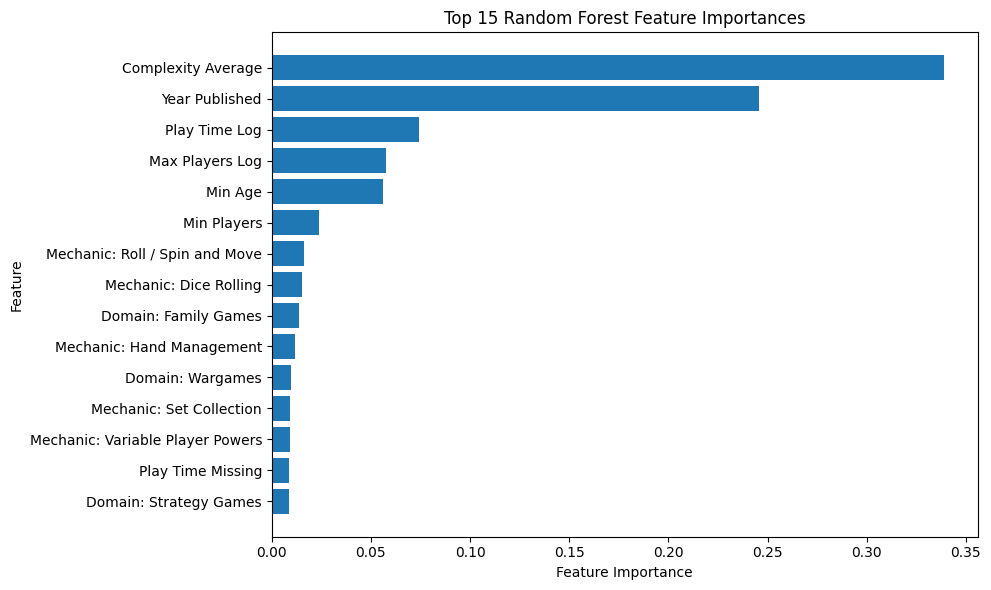

In [338]:
# Plot top 15 Random Forest feature importances
# same as "rounded top-feature table" but in chart
plt.figure(figsize=(10, 6))

plt.barh(
    top_15_feature_importance["Feature"],
    top_15_feature_importance["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [339]:
# Classify features into broad feature types
def classify_feature_type(feature_name):
    """Classify a model feature into a broad feature type."""
    # checking for feature starting witrh "Mechanic"
    if feature_name.startswith("Mechanic:"):
        return "Mechanic"
    # check if feature anme starts with "domain"
    if feature_name.startswith("Domain:"):
        return "Domain"
    # Check for ending with "missing"
    # -> fallback category
    if feature_name.endswith("Missing"):
        return "Missing Indicator"
    # if neither above then treat as numberical
    return "Numerical"

# creates a new column in the feature_importance table called "feature type"
feature_importance["Feature Type"] = feature_importance["Feature"].apply(
    classify_feature_type
)
# creats new table named "feature_type_importance"
feature_type_importance = (
    feature_importance
    .groupby("Feature Type", as_index=False)["Importance"]
    .sum()
    .sort_values("Importance", ascending=False)
)
# raw importance values add up to 1.0 (x 100 for %)
feature_type_importance["Importance Percentage"] = (
    feature_type_importance["Importance"] * 100
)
# create copy of table to keep original
feature_type_importance_rounded = feature_type_importance.copy()

feature_type_importance_rounded[
    ["Importance", "Importance Percentage"]
] = (
    feature_type_importance_rounded[
        ["Importance", "Importance Percentage"]
    ]
    .round(4)
)
# display table
feature_type_importance_rounded

,Feature Type,Importance,Importance Percentage
3,Numerical,0.7966,79.6579
1,Mechanic,0.1229,12.2856
0,Domain,0.0545,5.4495
2,Missing Indicator,0.0261,2.6069


In [340]:
# Save Random Forest feature importance results
random_forest_feature_importance_path = (
    processed_data_folder / "random_forest_feature_importance.csv"
)

feature_importance.to_csv(
    random_forest_feature_importance_path,
    index=False
)

print("Random Forest feature importance saved successfully.")
print("File exists:", random_forest_feature_importance_path.exists())

Random Forest feature importance saved successfully.
File exists: True


In [341]:
# Conclusion from Random Forest feature importance review in plain language
top_5_features = feature_importance.head(5)["Feature"].tolist()

feature_importance_conclusion = (
    "The Random Forest model relied most heavily on these top features: "
    f"{', '.join(top_5_features)}. "
    "These feature importance values help explain the model, but they should "
    "not be intepreted as proof that these features directly cause higher or "
    "lower board game ratings."
)

feature_importance_conclusion

'The Random Forest model relied most heavily on these top features: Complexity Average, Year Published, Play Time Log, Max Players Log, Min Age. These feature importance values help explain the model, but they should not be intepreted as proof that these features directly cause higher or lower board game ratings.'

### Feature Importance Review Result

Random Forest feature importance values were extracted and reviewed.

The feature importance table ranks all 35 model features from most important to least important.

A top-15 feature importance chart was created to make the most important predictors easier to review.

Feature importance was also grouped by broad feature type to understand whether the model relied more on numerical features, mechanics, domains, or missing-value indicators.

The Random Forest feature importance table was saved in the `data/processed` folder.

These results help explain the model, but they should not be interpreted as causal proof.

## Save Best Model

The model comparison showed that Random Forest performed best across all test-set metrics.

The trained Random Forest model is saved so it can be reused later without retraining.

Saving the model is important for future deployment because the Streamlit dashboard will need to load the trained model and use it to make predictions.

In [342]:
# Create folder for saved machine-learning models
models_folder = project_root / "models"

models_folder.mkdir(exist_ok=True)

print("Models folder:", models_folder)
print("Models folder exists:", models_folder.exists())

Models folder: c:\Users\Zombie\Desktop\vscode-projects\board-game-rating-predictor\models
Models folder exists: True


In [343]:
# Confirm the best model selected during model comparison
# -> to confirms that correct model is saved
print("Best model by Test MAE:", best_model_by_test_mae)
print("Best model by Test RMSE:", best_model_by_test_rmse)
print("Best model by Test R2:", best_model_by_test_r2)

Best model by Test MAE: Random Forest
Best model by Test RMSE: Random Forest
Best model by Test R2: Random Forest


In [344]:
# Define the selected best model and path whetre it will be saved
best_model_name = "Random Forest"
best_model = random_forest_model

best_model_path = models_folder / "random_forest_rating_model.joblib"

print("Best model name:", best_model_name)
print("Best model save path:", best_model_path)

Best model name: Random Forest
Best model save path: c:\Users\Zombie\Desktop\vscode-projects\board-game-rating-predictor\models\random_forest_rating_model.joblib


In [345]:
# Save the trained best model to disk
joblib.dump(best_model, best_model_path)

print("Best model saved successfully.")
print("File exists:", best_model_path.exists())

Best model saved successfully.
File exists: True


In [346]:
# Load saved model back - safety check
# -> confirmation that saved file can be reloaded
loaded_best_model = joblib.load(best_model_path)

print("Saved model loaded successfully.")
print("Loaded model type:", type(loaded_best_model))
print("Loaded model number of features:", loaded_best_model.n_features_in_)

Saved model loaded successfully.
Loaded model type: <class 'sklearn.ensemble._forest.RandomForestRegressor'>
Loaded model number of features: 35


In [347]:
# Compare predictions from original model VS loaded model
# Safety check -> confirmation match
original_model_sample_predictions = best_model.predict(X_test.head(5))
loaded_model_sample_predictions = loaded_best_model.predict(X_test.head(5))

# table with 2 comuns - side by side checking
prediction_check = pd.DataFrame(
    {
        "Original Model Prediction": original_model_sample_predictions,
        "Loaded Model Prediction": loaded_model_sample_predictions
    }
)

# new column "Absolute Difference"
prediction_check["Absolute Difference"] = (
    prediction_check["Original Model Prediction"]
    - prediction_check["Loaded Model Prediction"]
).abs()

# new colum "Predictions Match Within Tolerance"
# "np.isclose" -> checks if 2 numbers are close enough to count as match
prediction_check["Predictions Match Within Tolerance"] = np.isclose(
    prediction_check["Original Model Prediction"],
    prediction_check["Loaded Model Prediction"],
    rtol=1e-10,
    atol=1e-10
)

# ".all()" -> are all values in column true
print(
    "All predictions match within tolerance:",
    prediction_check["Predictions Match Within Tolerance"].all()
)

print(
    "Maximum absolute difference:",
    prediction_check["Absolute Difference"].max()
)

prediction_check

All predictions match within tolerance: True
Maximum absolute difference: 1.7763568394002505e-15


,Original Model Prediction,Loaded Model Prediction,Absolute Difference,Predictions Match Within Tolerance
0,6.5242,6.5242,0.000000e+00,True
1,6.4193,6.4193,1.776357e-15,True
2,7.1308,7.1308,1.776357e-15,True
3,6.4677,6.4677,0.000000e+00,True
4,7.6670,7.6670,0.000000e+00,True


In [348]:
# Save shrot best-model summary for documentation
best_model_summary = pd.DataFrame(
    [
        {
            "Best Model": best_model_name,
            "Test MAE": random_forest_test_results["MAE"],
            "Test RMSE": random_forest_test_results["RMSE"],
            "Test R2": random_forest_test_results["R2"],
            "Model File": str(best_model_path.relative_to(project_root)),
            "Number of Features": best_model.n_features_in_,
            "Selection Reason": (
                "Random Forest had the best test-set MAE, RMSE, and R2 "
                "among the models compared."
            )
        }
    ]
)

best_model_summary_path = (
    processed_data_folder / "best_model_summary.csv"
)

best_model_summary.to_csv(
    best_model_summary_path,
    index=False
)

print("Best model summary saved successfully.")
print("File exists:", best_model_summary_path.exists())

best_model_summary

Best model summary saved successfully.
File exists: True


,Best Model,Test MAE,Test RMSE,Test R2,Model File,Number of Features,Selection Reason
0,Random Forest,0.491151,0.664943,0.499325,models\random_forest_rating_model.joblib,35,"Random Forest had the best test-set MAE, RMSE,..."


In [349]:
# Create short conclusion for the saved best model
saved_model_conclusion = (
    f"The selected best model is {best_model_name}. "
    f"It was saved to {best_model_path.relative_to(project_root)}. "
    f"The saved model uses {best_model.n_features_in_} prepared input features. "
    "The model was loaded back successfully and produced matching predictions "
    "within floating-point tolerance against the original trained model on a "
    "small test sample."
)

saved_model_conclusion

'The selected best model is Random Forest. It was saved to models\\random_forest_rating_model.joblib. The saved model uses 35 prepared input features. The model was loaded back successfully and produced matching predictions within floating-point tolerance against the original trained model on a small test sample.'

### Saved Best Model Result

The Random Forest model was selected as the best model because it performed best across the test-set metrics.

The trained Random Forest model was saved in the `models` folder.

The saved model was loaded back successfully to confirm that the file works.

Predictions from the original trained model and the loaded saved model matched on a small test sample.

A best-model summary file was also saved in the `data/processed` folder for future documentation.